# Streaming training with LSDB datasets

## Open a TESS lightcurve catalog
We'll open the TESS lightcurve catalog from LSDB and filter down the observations
to non-NaN values and ensure that the lightcurves have at least 100 observations.


In [1]:
import lsdb

tess = lsdb.open_catalog("https://data.lsdb.io/hats/tess/tess_lightcurve")

In [2]:
def drop_nans(df):
    # 1. Drop the rows where lightcurve.sap_flux is NaN
    # 2. Also remove all the resulting objects with no lightcurve points remaining
    df["lightcurve.sap_flux"] = df["lightcurve.sap_flux"].astype(float)
    return df.dropna(subset=["lightcurve.sap_flux"]).dropna(subset=["lightcurve"])


tess_filtered_nans = tess.map_partitions(drop_nans)

from nested_pandas.utils import count_nested


def count_points(pts):
    # Asked to count `lightcurve`, this will add a column called `n_lightcurve`
    return count_nested(pts, "lightcurve")


min_observations = 100
tess_filtered_nans = tess_filtered_nans.map_partitions(count_points).query(
    f"n_lightcurve >= {min_observations}"
)

## Hyrax section
Instantiate Hyrax and define the data request using `LSDBStreamDataset`, which needs no
per-survey subclass: it collates every nested column into a padded `<column>_<subcolumn>`
array plus a boolean `<column>_<subcolumn>_mask`.

`HyraxTs2Vec.prepare_inputs` turns those columns into the `(batch, time, channels)` event
sequence the encoder consumes, reading the column names and the encoding settings from
`[model.HyraxTs2Vec]`.

In [3]:
from hyrax import Hyrax
from hyrax.datasets import LSDBStreamDataset

h = Hyrax()

In [4]:
LSDBStreamDataset.register_catalog("tess_catalog", tess_filtered_nans)

data_request = {
    "train_stream": {
        "data": {
            "dataset_class": "LSDBStreamDataset",
            "data_location": "lsdb://tess_catalog",
            "primary_id_field": "ticid",
            "fields": [
                "lightcurve_time",
                "lightcurve_sap_flux",
                "lightcurve_sap_flux_err",
            ],
        }
    }
}
h.set_config("data_request", data_request)

h.set_config("model.name", "HyraxTs2Vec")

# Point the model at this catalog's columns. TESS is single-band, so there is no band
# column: band_field = False drops the one-hot block, leaving 3 channels - flux, flux
# error, and log time gap.
h.set_config("model.HyraxTs2Vec.band_field", False)
h.set_config("model.HyraxTs2Vec.time_field", "lightcurve_time")
h.set_config("model.HyraxTs2Vec.flux_field", "lightcurve_sap_flux")
h.set_config("model.HyraxTs2Vec.flux_err_field", "lightcurve_sap_flux_err")
h.set_config("model.HyraxTs2Vec.max_sequence_length", 256)

# Training wants an endless stream; the default "catalog" makes exactly one pass and stops.
h.set_config("data_set.LSDBStreamDataset.stream_type", "infinite")
h.set_config("data_set.LSDBStreamDataset.partitions_per_chunk", 2)

# Each TESS object carries thousands of cadences, which are padded to the longest curve in
# the batch before being trimmed to max_sequence_length, so 512 makes for a heavy batch.
h.set_config("data_loader.batch_size", 64)

In [5]:
import tqdm
from dask.distributed import Client

batch_counter = 0
MAX_BATCHES = 100

# This allows use to define our own Dask client.
# with Client(n_workers=2, threads_per_worker=1, memory_limit="8GB") as client:
#     print("Client dashboard:", client.dashboard_link)
#     with h.train_stream() as session:
#         for batch, metrics in tqdm.tqdm(session):
#             batch_counter += 1

#             if batch_counter >= MAX_BATCHES:
#                 break
#     client.close()


with h.train_stream() as session:
    for batch, metrics in tqdm.tqdm(session):
        batch_counter += 1

        if batch_counter >= MAX_BATCHES:
            break

[2026-09-23 13:44:49,282 hyrax.datasets.lsdb_stream_dataset:INFO] No active dask.distributed Client was found, so lsdb will compute each chunk synchronously and every fetch will block the consumer. Create a client before starting the run - Client(processes=False) keeps results in-process and avoids serializing every chunk back from a worker.
[2026-09-23 13:44:49,283 hyrax.datasets.lsdb_stream_dataset:WARNING] config['data_set']['LSDBStreamDataset']['shuffle'] is ignored when stream_type = 'infinite'; lsdb's InfiniteStream always shuffles.
[2026-09-23 13:45:20,172 hyrax.models.model_registry:WARNING] Both model and config define an optimizer. Hyrax will use self.optimizer defined in the model.
[2026-09-23 13:45:20,173 hyrax.models.model_registry:INFO] Using self.optimizer defined in model: torch.optim.adamw.AdamW
[2026-09-23 13:45:20,173 hyrax.models.model_registry:WARNING] Both model and config define a criterion. Hyrax will use self.criterion defined in the model.
[2026-09-23 13:45:20

In [6]:
from hyrax.config_utils import find_most_recent_results_dir

data_request = {
    "infer_stream": {
        "data": {
            "dataset_class": "LSDBStreamDataset",
            "data_location": "lsdb://tess_catalog",
            "primary_id_field": "ticid",
            "fields": [
                "lightcurve_time",
                "lightcurve_sap_flux",
                "lightcurve_sap_flux_err",
            ],
        }
    }
}
h.set_config("data_request", data_request)

h.set_config("model.name", "HyraxTs2Vec")

# Point the model at this catalog's columns. TESS is single-band, so there is no band
# column: band_field = False drops the one-hot block, leaving 3 channels - flux, flux
# error, and log time gap.
h.set_config("model.HyraxTs2Vec.band_field", False)
h.set_config("model.HyraxTs2Vec.time_field", "lightcurve_time")
h.set_config("model.HyraxTs2Vec.flux_field", "lightcurve_sap_flux")
h.set_config("model.HyraxTs2Vec.flux_err_field", "lightcurve_sap_flux_err")
h.set_config("model.HyraxTs2Vec.max_sequence_length", 256)

# Inference wants a single finite pass, visiting every object exactly once.
h.set_config("data_set.LSDBStreamDataset.stream_type", "catalog")
h.set_config("data_set.LSDBStreamDataset.shuffle", False)

h.set_config("infer_stream.save_model_output", True)

h.set_config("data_loader.batch_size", 256)


train_dir = find_most_recent_results_dir(h.config, "train_stream")
h.set_config(
    "infer_stream.model_weights_file",
    str(train_dir / h.config["train_stream"]["weights_filename"]),
)

[2026-09-23 13:45:47,010 hyrax.config_utils:WARNING] Runtime config contains key or section 'infer_stream' which has no default defined. All configuration keys and sections must be defined in /home/drew/code/hyrax-wt-ts2vec/src/hyrax/hyrax_default_config.toml


In [7]:
batch_counter = 0
MAX_BATCHES = 100

with h.infer_stream() as session:
    for batch, metrics in tqdm.tqdm(session):
        batch_counter += 1

        if batch_counter >= MAX_BATCHES:
            break

[2026-09-23 13:45:47,229 hyrax.datasets.lsdb_stream_dataset:INFO] No active dask.distributed Client was found, so lsdb will compute each chunk synchronously and every fetch will block the consumer. Create a client before starting the run - Client(processes=False) keeps results in-process and avoids serializing every chunk back from a worker.
[2026-09-23 13:46:08,180 hyrax.models.model_registry:WARNING] Both model and config define an optimizer. Hyrax will use self.optimizer defined in the model.
[2026-09-23 13:46:08,181 hyrax.models.model_registry:INFO] Using self.optimizer defined in model: torch.optim.adamw.AdamW
[2026-09-23 13:46:08,181 hyrax.models.model_registry:WARNING] Both model and config define a criterion. Hyrax will use self.criterion defined in the model.
[2026-09-23 13:46:08,181 hyrax.models.model_registry:INFO] Using self.criterion defined in model: hyrax.models.hyrax_ts2vec.HierarchicalContrastiveLoss
[2026-09-23 13:46:08,182 hyrax.models.model_registry:INFO] Setting mo

In [8]:
infer_dir = find_most_recent_results_dir(h.config, "infer_stream")
umap_results = h.reduce_dimensions(input_dir=infer_dir)

[2026-09-23 13:54:05,247 hyrax.verbs.reduce_dimensions:INFO] Saving reduction results using umap to /home/drew/code/hyrax-wt-ts2vec/docs/pre_executed/results/20260923-135405-umap-f9lY
[2026-09-23 13:54:05,248 hyrax.verbs.reduce_dimensions:INFO] Using most recent inference results dataset for dimensionality reduction.
[2026-09-23 13:54:06,108 hyrax.verbs.reduce_dimensions:INFO] No model_path specified. A new model will be fitted.
[2026-09-23 13:54:06,108 hyrax.verbs.reduction_algorithms.umap:INFO] Fitting the UMAP
[2026-09-23 13:54:12,619 hyrax.verbs.reduce_dimensions:INFO] Saving fitted umap reducer to result directory


Creating lower dimensional representation using UMAP::   0%|          | 0/25 [00:00<?, ?it/s]

[2026-09-23 13:54:53,882 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 25 batches
[2026-09-23 13:54:53,896 hyrax.datasets.result_dataset:INFO] Lance table optimization complete
[2026-09-23 13:54:53,896 hyrax.verbs.reduce_dimensions:INFO] Finished transforming all data with umap


In [9]:
import numpy as np

# Stack all UMAP embeddings into a single array.
umap_embeddings = np.array([umap_results[i] for i in range(len(umap_results))])
print(f"Shape: {umap_embeddings.shape}  (samples × components)")

Shape: (25600, 2)  (samples × components)


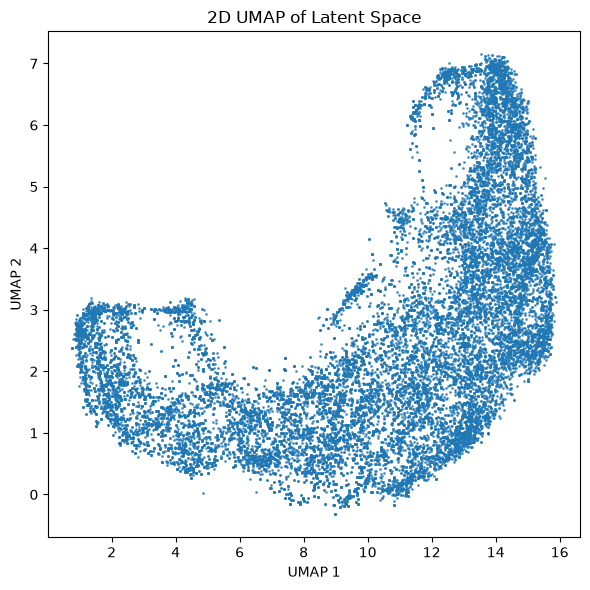

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], s=1, alpha=0.7)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("2D UMAP of Latent Space")
plt.tight_layout()
plt.show()